# Tema 4 - Introducción a Scikit-learn (Regresión lineal)

Este notebook guía paso a paso el uso de **Scikit-learn** para construir un modelo
de **regresión lineal**. Está pensado para estudiantes que están viendo Machine Learning
por primera vez.

Objetivos:

1. Entender el flujo básico de trabajo con Scikit-learn.
2. Preparar las variables de entrada (X) y salida (y).
3. Dividir los datos en entrenamiento y prueba.
4. Entrenar un modelo de regresión lineal.
5. Evaluar el modelo con métricas básicas.
6. Interpretar los resultados y realizar pequeños ajustes.


## 1. Instalación de librerías necesarias

Librerías que se utilizarán:

- `numpy` y `pandas` para manipulación de datos.
- `matplotlib` para gráficos.
- `scikit-learn` para construir y evaluar el modelo.

Si en tu entorno ocurre un error de importación, puedes instalar las librerías con:

En una terminal del sistema operativo o en el panel de terminal de VS Code:

```bash
pip install numpy pandas matplotlib scikit-learn
```

También puedes ejecutarlo desde una celda de Jupyter, anteponiendo `!`:

```python
# Ejecutar solo si tienes problemas de importación
# !pip install numpy pandas matplotlib scikit-learn
```


In [ ]:
#!pip install numpy pandas matplotlib scikit-learn

## 2. Importar librerías

Primero se importan todas las librerías que se utilizarán en el notebook.


In [2]:
# Librerías para análisis de datos y gráficos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Funciones de Scikit-learn para el flujo de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Hacer que los gráficos se muestren dentro del notebook
%matplotlib inline

## 3. Crear el conjunto de datos de ejemplo

En este ejemplo simularemos datos de una empresa que invierte en publicidad
y quiere entender la relación entre el **gasto en publicidad** y las **ventas**.

Generaremos un conjunto de datos sintético con una relación aproximadamente lineal.


In [3]:
# Fijar la semilla aleatoria para que los resultados sean reproducibles
np.random.seed(42)

# Número de observaciones
n = 150

# Gasto en publicidad entre 1000 y 10000 colones
gasto_publicidad = np.random.randint(1000, 10000, size=n)

# Ruido aleatorio para simular la variabilidad real
ruido = np.random.normal(loc=0, scale=5000, size=n)

# Relación lineal simulada: ventas ≈ 3 * gasto_publicidad + 200000 + ruido
ventas = (3 * gasto_publicidad + 200_000 + ruido).round().astype(int)

# Construir el DataFrame
df = pd.DataFrame({
    "gasto_publicidad": gasto_publicidad,
    "ventas": ventas
})

# Ver las primeras filas
df.head(10)

,gasto_publicidad,ventas
0,8270,222394
1,1860,202731
2,6390,208712
3,6191,224892
4,6734,220125
5,7265,221658
6,1466,208487
7,5426,211005
8,6578,215942
9,9322,230253


## 4. Exploración inicial de los datos

Antes de entrenar el modelo, revisamos:

- Estructura del DataFrame.
- Estadísticas básicas.
- Relación gráfica entre las variables.


In [4]:
# Información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   gasto_publicidad  150 non-null    int64
 1   ventas            150 non-null    int64
dtypes: int64(2)
memory usage: 2.5 KB


In [5]:
# Estadísticas descriptivas de las columnas numéricas
df.describe()

,gasto_publicidad,ventas
count,150.000000,150.000000
mean,5804.393333,217189.786667
std,2594.488195,9312.360428
min,1064.000000,196398.000000
25%,3632.250000,209972.750000
50%,6267.000000,217324.500000
75%,8013.500000,224867.000000
max,9996.000000,235724.000000


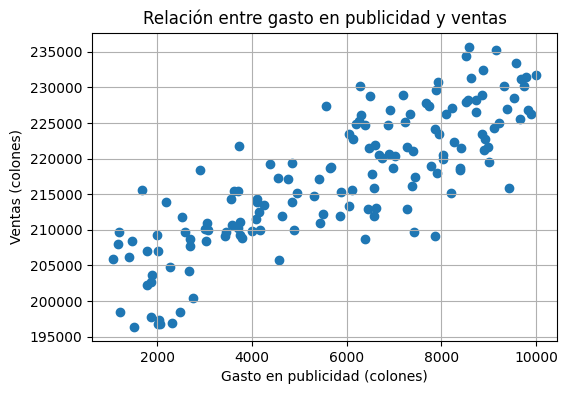

In [6]:
# Gráfico de dispersión entre gasto en publicidad y ventas
plt.figure(figsize=(6, 4))
plt.scatter(df["gasto_publicidad"], df["ventas"])
plt.xlabel("Gasto en publicidad (colones)")
plt.ylabel("Ventas (colones)")
plt.title("Relación entre gasto en publicidad y ventas")
plt.grid(True)
plt.show()

## 5. Definir variables de entrada (X) y salida (y)

En un modelo supervisado:

- `X` es la matriz de características (variables que usamos para predecir).
- `y` es la variable objetivo (lo que queremos predecir).

En este caso:

- `X` = gasto_publicidad  
- `y` = ventas


In [7]:
# Matriz de características (X) como DataFrame
X = df[["gasto_publicidad"]]

# Variable objetivo (y) como Serie
y = df["ventas"]

X.head(), y.head()

(   gasto_publicidad
 0              8270
 1              1860
 2              6390
 3              6191
 4              6734,
 0    222394
 1    202731
 2    208712
 3    224892
 4    220125
 Name: ventas, dtype: int64)

## 6. División en entrenamiento y prueba

Para evaluar el modelo de forma honesta, dividimos los datos en:

- Conjunto de entrenamiento: para ajustar el modelo.
- Conjunto de prueba: para evaluar qué tan bien generaliza.

Usaremos 80% para entrenamiento y 20% para prueba.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% de los datos para prueba
    random_state=42     # Semilla para reproducibilidad
)

len(X_train), len(X_test)

(120, 30)

## 7. Crear y entrenar el modelo de regresión lineal

Scikit-learn utiliza el concepto de *estimador*:

1. Se crea el modelo (por ejemplo, `LinearRegression()`).
2. Se entrena con `.fit(X_train, y_train)`.
3. Se generan predicciones con `.predict(X_test)`.


In [10]:
# Crear el modelo de regresión lineal
modelo = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

# Ver los parámetros aprendidos por el modelo
coeficiente = modelo.coef_[0]
intercepto = modelo.intercept_

print("Coeficiente (pendiente):", coeficiente)
print("Intercepto:", intercepto)

Coeficiente (pendiente): 3.0514304934484917
Intercepto: 199117.04865278478


## 8. Predicciones y evaluación del modelo

Con el modelo entrenado:

1. Generamos predicciones para el conjunto de prueba.
2. Calculamos las métricas de error:

- **MSE**: error cuadrático medio.
- **RMSE**: raíz del error cuadrático medio.
- **R²**: proporción de la variabilidad explicada por el modelo.


In [13]:
# Generar predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

# Calcular métricas de evaluación
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 25339975.35491578
RMSE: 5033.882731541904
R²: 0.5599806239205959


## 9. Visualización del modelo

Para complementar las métricas numéricas, visualizamos:

- Puntos reales del conjunto de prueba.
- Línea estimada por el modelo.


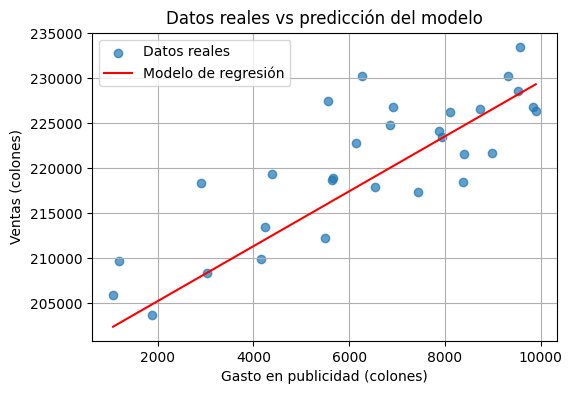

In [12]:
plt.figure(figsize=(6, 4))

# Puntos reales
plt.scatter(X_test, y_test, label="Datos reales", alpha=0.7)

# Ordenar X_test para dibujar una línea continua
X_test_sorted = X_test.sort_values(by="gasto_publicidad")
y_pred_sorted = modelo.predict(X_test_sorted)

plt.plot(X_test_sorted, y_pred_sorted, color="red", label="Modelo de regresión")

plt.xlabel("Gasto en publicidad (colones)")
plt.ylabel("Ventas (colones)")
plt.title("Datos reales vs predicción del modelo")
plt.legend()
plt.grid(True)
plt.show()

## 10. Ejercicio 

1. Crear una nueva columna `ventas_millones` que convierta las ventas a millones de colones.
2. Volver a definir `y` usando `ventas_millones`.
3. Repetir el flujo completo: división, modelo, entrenamiento, métricas.
4. Comparar las métricas con las obtenidas originalmente.

Preguntas:

- ¿Cambia el valor de RMSE?
- ¿Cambia el valor de R²?


In [ ]:

# 1. Crear la columna ventas_millones

df["ventas_millones"] = df['ventas']*10


In [ ]:
# 2. Redefinir y
y_millones = df['ventas_millones']


In [26]:
# 3. Repetir división, entrenamiento y evaluación

# División

X_train, X_test, y_millones_train, y_millones_test = train_test_split(
    X, y_millones,
    test_size=0.2,      # 20% de los datos para prueba
    random_state=42     # Semilla para reproducibilidad
)

len(X_train), len(X_test)

(120, 30)

In [27]:
#Entrenamiento

# Crear el modelo de regresión lineal
modelo = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
modelo.fit(X_train, y_millones_train)

# Ver los parámetros aprendidos por el modelo
coeficiente = modelo.coef_[0]
intercepto = modelo.intercept_

print("Coeficiente (pendiente):", coeficiente)
print("Intercepto:", intercepto)

Coeficiente (pendiente): 30.514304934484908
Intercepto: 1991170.4865278476


In [29]:
#Evaluación
# Generar predicciones sobre el conjunto de prueba
y_millones_pred = modelo.predict(X_test)

# Calcular métricas de evaluación
mse = mean_squared_error(y_test, y_millones_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_millones_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 2533997535.491585
RMSE: 50338.827315419105
R²: 0.5599806239205947


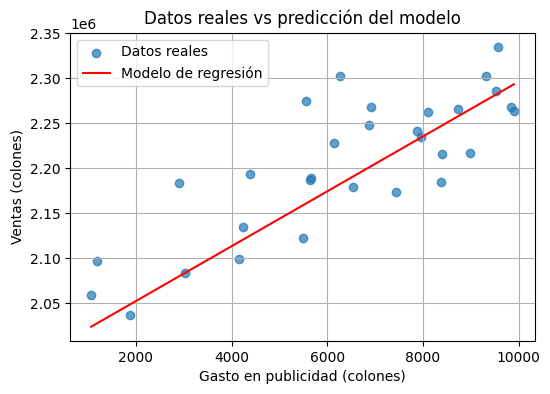

In [30]:
# Visualización
plt.figure(figsize=(6, 4))

# Puntos reales
plt.scatter(X_test, y_millones_test, label="Datos reales", alpha=0.7)

# Ordenar X_test para dibujar una línea continua
X_test_sorted = X_test.sort_values(by="gasto_publicidad")
y_pred_sorted = modelo.predict(X_test_sorted)

plt.plot(X_test_sorted, y_pred_sorted, color="red", label="Modelo de regresión")

plt.xlabel("Gasto en publicidad (colones)")
plt.ylabel("Ventas (colones)")
plt.title("Datos reales vs predicción del modelo")
plt.legend()
plt.grid(True)
plt.show()

## Comparación 

Como solo hubo que agregarle un 0 para que fueran millones, no hay mucha diferencia, simplemente aumentan el tamaño de las cifras, pero el comportamiento se mantiene igual.

## 11. Cierre

En este notebook aplicaste el flujo básico de Scikit-learn:

1. Crear o cargar datos.
2. Explorar el dataset.
3. Definir X e y.
4. Dividir en entrenamiento y prueba.
5. Entrenar un modelo simple de regresión.
6. Evaluar resultados con métricas y gráficos.

Este mismo flujo se reutiliza con otros modelos cambiando únicamente la clase
del estimador (por ejemplo, `LinearRegression` por otro algoritmo).
